# Libraries

In [2]:
%matplotlib qt

##modules
#%matplotlib widget
%matplotlib inline
#
#%matplotlib qt
import mne
import numpy as np
import matplotlib
# Establecer un backend interactivo, como 'Qt5Agg', 'GTK3Agg', etc.
# Esto depende de los backends disponibles en tu sistema.

import matplotlib.pyplot as plt

#matplotlib.use('TkAgg')  # Asegúrate de que este backend está instalado.

import pandas as pd 
import os
import sys

from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs

from os.path import join as pathjoin
from time import time

from pathlib import Path

from autoreject import AutoReject

# aplicar la acf EN epochs

from statsmodels.tsa.stattools import acf


from scipy.stats import permutation_test
sys.path.append(r"G:\apuntes_mne\code_MOUS\scripts_functions_created")

# Ahora importa la función
from print5 import print5


import pickle

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
# Import required code for visualizing example models
from fooof import FOOOF
from fooof.sim.gen import gen_power_spectrum
from fooof.sim.utils import set_random_seed
from fooof.plts.spectra import plot_spectra
from fooof.plts.annotate import plot_annotated_model
from fooof import FOOOFGroup,Bands
from fooof.analysis.periodic import get_band_peak_group, get_band_peak

C:\Users\UCM\AppData\Local\Temp\ipykernel_7868\2329846024.py:50: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


# paths

In [3]:

try:
    # Si se ejecuta como SCRIPT .py: usar __file__
    sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
except NameError:
    # Si se ejecuta como NOTEBOOK Jupyter: usar path relativo
    sys.path.append("..")  # sube un nivel desde la carpeta actual del notebook


# --- Configuración dinámica de rutas ---
from get_paths_SELF import get_paths_SELF

# Parámetros editables
disco = "g"
modality="visual"
layer_script = "event"
subj= "s01b"
type_epoch="emoc"

# Generar variables automáticamente
path_dict = get_paths_SELF(disco=disco, modality=modality,layer_script=layer_script,  subj=subj)
globals().update(path_dict)

# Mostrar todos los paths generados
print("\n📁 Rutas generadas:")
for k, v in path_dict.items():
    print(f"{k:<20} → {v}")

    


✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\ICA_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_clean_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_matlab_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\evoked_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\channels_structure
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event\raw_hsp
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event\fwd
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event\inverse
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_analysis\analysis_event\acw_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_analysis\analysis_eve

In [4]:
subjects_BV = []

# Define modality pattern
if modality == "visual":
    pattern_modality = "_vis_"
elif modality == "auditory":
    pattern_modality = "_aud_"
else:
    pattern_modality = None
    
    
filtering=True
if filtering==True:
    lfreq=1
    hfreq=40
    filter_name= f"filt_{lfreq}-{hfreq}"
    print(f"Filtrado aplicado: {lfreq}-{hfreq} Hz")
elif filtering==False:
    print("No se ha aplicado filtrado.")
    
    
# Read subject names from .vhdr files in export_generic_data
for archivo in export_generic_data.glob("*.vhdr"):
    nombre = archivo.stem  # filename without extension

    # Keep only files matching the selected modality
    if pattern_modality is not None and pattern_modality in nombre:
        sujeto = nombre.split("_")[0].lower()  # e.g. s01b_vis_c_BV_mne -> s01b
        subjects_BV.append(sujeto)

# Remove duplicates and sort ignoring case
subjects_BV = sorted(set(subjects_BV), key=str.lower)

print("Subjects found:")
print(subjects_BV)


Filtrado aplicado: 1-40 Hz
Subjects found:
['s01b', 's02b', 's03b', 's04b', 's05b', 's06b', 's07b', 's08b', 's09b', 's10b', 's11b', 's12b', 's13b', 's14b', 's15b', 's16b', 's17b', 's18b', 's19b', 's20b', 's21b', 's22b', 's23b', 's24b', 's25b', 's26b', 's27b', 's28b', 's29b', 's30b', 's31b', 's32b', 's33b', 's34b', 's35b', 's36b']


In [6]:
subject=subjects_BV[0]

In [15]:
epochs.events

array([[   644,      0,     36],
       [  2821,      0,     55],
       [  4996,      0,     14],
       [  9348,      0,     66],
       [ 11524,      0,     16],
       [ 13700,      0,     26],
       [ 15876,      0,     15],
       [ 18052,      0,     24],
       [ 20229,      0,     86],
       [ 22404,      0,     14],
       [ 24581,      0,     16],
       [ 26756,      0,     85],
       [ 28932,      0,     74],
       [ 31108,      0,     56],
       [ 33284,      0,     45],
       [ 35461,      0,     66],
       [ 37637,      0,     26],
       [ 39813,      0,     16],
       [ 41989,      0,     44],
       [ 44165,      0,     84],
       [ 46340,      0,     56],
       [ 48516,      0,     54],
       [ 50692,      0,     14],
       [ 52868,      0,     85],
       [ 55044,      0,     65],
       [ 57220,      0,     36],
       [ 59397,      0,     36],
       [ 61572,      0,     45],
       [ 63748,      0,     84],
       [ 65924,      0,     54],
       [ 7

In [5]:
type_epoch="full"

In [27]:
subject = subjects_BV[0]

# 📂 Cargar epochs limpios
epochs_file = epochs_clean_path / f"{subject}_epochs_{type_epoch}-epo.fif"
epochs = mne.read_epochs(epochs_file)
# if filtering:
#     filter_applied=True
#     epochs.filter(l_freq=lfreq, h_freq=hfreq)
#     print(f"Filter applied to {subj}: {lfreq}-{hfreq} Hz")


Reading g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_clean_event\s01b_epochs_full-epo.fif ...
    Found the data of interest:
        t =   -2000.00 ...    6000.00 ms
        0 CTF compensation matrices available
Not setting metadata
212 matching events found
No baseline correction applied
0 projection items activated


In [28]:
epochs.plot(
    events=epochs.events,
    event_id=epochs.event_id,
    # n_epochs=5,
    # n_channels=30,
    # block=True
)



C:\Users\UCM\AppData\Local\Temp\ipykernel_7868\4113030263.py:1: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  epochs.plot(


In [13]:
event_dict = epochs.event_id
event_dict

{'14': 14,
 '15': 15,
 '16': 16,
 '24': 24,
 '25': 25,
 '26': 26,
 '34': 34,
 '35': 35,
 '36': 36,
 '44': 44,
 '45': 45,
 '46': 46,
 '54': 54,
 '55': 55,
 '56': 56,
 '64': 64,
 '65': 65,
 '66': 66,
 '74': 74,
 '75': 75,
 '76': 76,
 '84': 84,
 '85': 85,
 '86': 86,
 '94': 94,
 '95': 95,
 '96': 96}

In [22]:
# 📌 Extraer todas las condiciones automáticamente
event_dict = epochs.event_id
print("Condiciones detectadas en epochs:", event_dict)

evoked_list = []

for cond, event_code in event_dict.items():

    # # --- Renombrar condiciones según el tipo de script ---
    # if layer_script == "block" and cond.startswith("fix_"):
    #     new_cond = cond.replace("fix_", "")
    # elif layer_script == "event" and cond.startswith("begin_"):
    #     new_cond = cond.replace("begin_", "")
    # else:
    #     new_cond = cond  # mantener nombre original
    # print(f"Procesando condición: {cond} → {new_cond} (event code={event_code})")
    # # Guardar nombre de condición para recuperar después
    evk = epochs[cond].average(picks="all")
    # evk.comment = new_cond

    evoked_list.append(evk)

    # Opcional: chequeo rápido de canales
    channel_types = [mne.channel_type(evk.info, idx)
                     for idx in range(len(evk.info['ch_names']))]
    print("Resumen tipos de canales:", Counter(channel_types))


Condiciones detectadas en epochs: {'14': 14, '15': 15, '16': 16, '24': 24, '25': 25, '26': 26, '34': 34, '35': 35, '36': 36, '44': 44, '45': 45, '46': 46, '54': 54, '55': 55, '56': 56, '64': 64, '65': 65, '66': 66, '74': 74, '75': 75, '76': 76, '84': 84, '85': 85, '86': 86, '94': 94, '95': 95, '96': 96}
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos de canales: Counter({'eeg': 59, 'eog': 4, 'misc': 2})
Resumen tipos d

In [ ]:

# ✅ Guardar todas las condiciones en un único archivo
output_file = evoked_path / f"{subj}_evokeds_{layer_script}-ave.fif"
if filtering==True and filter_applied==True:
    output_file = evoked_path / f"{subj}_evokeds_{filter_name}_{layer_script}-ave.fif"
elif filtering==None:
    output_file = evoked_path / f"{subj}_evokeds_{layer_script}-ave.fif"

print("\n✅ Archivo Evoked creado:", output_file)
print("Condiciones guardadas:", [e.comment for e in evoked_list])

In [ ]:
evoked_list

[<Evoked | '14' (average, N=7), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '15' (average, N=9), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '16' (average, N=8), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '24' (average, N=7), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '25' (average, N=6), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '26' (average, N=9), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '34' (average, N=6), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '35' (average, N=7), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '36' (average, N=10), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '44' (average, N=10), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '45' (average, N=7), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '46' (average, N=6), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '54' (average, N=7), 0 – 6 s, baseline off, 65 ch, ~858 kB>,
 <Evoked | '55' (average, N=8), 0 – 6 s, baseline off, 65 ch, 

In [23]:
evoked=evoked_list[0]

In [29]:
evoked_list

[<Evoked | '14' (average, N=8), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '15' (average, N=8), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '16' (average, N=7), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '24' (average, N=9), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '25' (average, N=9), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '26' (average, N=9), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '34' (average, N=8), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '35' (average, N=8), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '36' (average, N=5), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '44' (average, N=9), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '45' (average, N=8), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '46' (average, N=6), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '54' (average, N=5), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>,
 <Evoked | '55' (average, N=10), -2 – 6 s, baseline

In [24]:
evoked = evoked_list[0]

# Copia info y datos
info = evoked.info.copy()
data = evoked.data.copy()

# Crear RawArray desde el Evoked
evoked_raw = mne.io.RawArray(data, info)

Creating RawArray with float64 data, n_channels=65, n_times=2049
    Range : 0 ... 2048 =      0.000 ...     8.000 secs
Ready.


In [30]:
evoked_raw.plot()

In [31]:
subject

's01b'

{'14': 14, '15': 15, '16': 16, '24': 24, '25': 25, '26': 26, '34': 34, '35': 35, '36': 36, '44': 44, '45': 45, '46': 46, '54': 54, '55': 55, '56': 56, '64': 64, '65': 65, '66': 66, '74': 74, '75': 75, '76': 76, '84': 84, '85': 85, '86': 86, '94': 94, '95': 95, '96': 96}
<Evoked | '0.35 × 14 + 0.35 × 24 + 0.30 × 34' (average, N=20), -2 – 6 s, baseline off, 65 ch, ~1.1 MB>
N épocas promediadas: 20


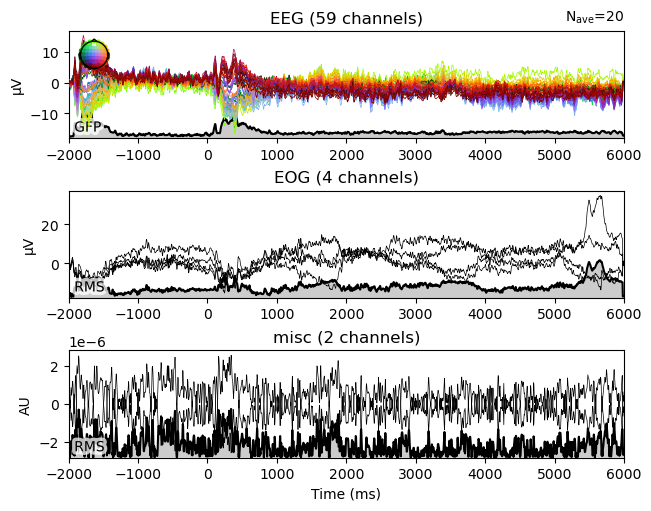

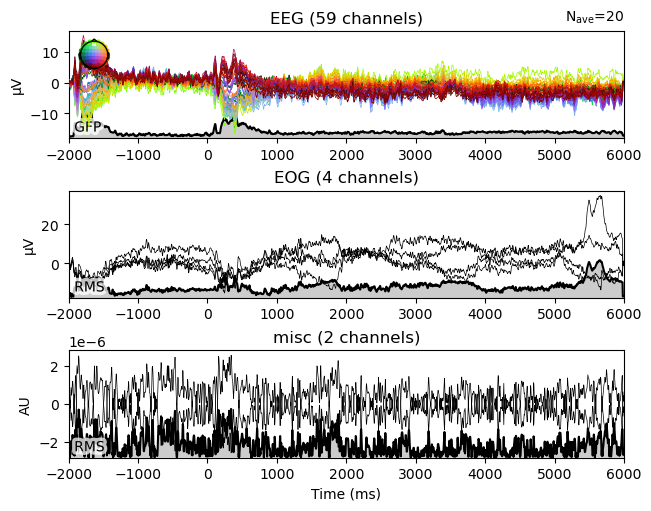

In [32]:
# Triggers que quieres promediar
triggers_self_pos = ["24", "14", "34"]

# Comprobar nombres reales de condiciones
print(epochs.event_id)

# Seleccionar esas épocas y hacer el promedio
evoked_self_pos = epochs[triggers_self_pos].average(picks="all")

# Comprobar
print(evoked_self_pos)
print("N épocas promediadas:", evoked_self_pos.nave)

# Plot normal de evoked
evoked_self_pos.plot(
    spatial_colors=True,
    gfp=True,
    time_unit="ms"
)

In [33]:
evoked_self_pos_raw = mne.io.RawArray(
    evoked_self_pos.data.copy(),
    evoked_self_pos.info.copy()
)

evoked_self_pos_raw.plot(
    # duration=6,
    # n_channels=30,
    # scalings="auto",
    # block=True
)

Creating RawArray with float64 data, n_channels=65, n_times=2049
    Range : 0 ... 2048 =      0.000 ...     8.000 secs
Ready.


Channels marked as bad:
none
